In [17]:
import pandas as pd
from scipy.stats import ttest_ind
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('Churn_Modelling.csv')

# Гипотеза 1

Нулевая гипотеза (H₀): Средний возраст клиентов, которые ушли, равен среднему возрасту клиентов, которые остались.

Альтернативная гипотеза (H₁): Средний возраст клиентов, которые ушли, отличается от среднего возраста тех, кто остался.

Используем: t-test (две независимые выборки - клиенты, которые ушли (Exited = 1) и  клиенты, которые остались (Exited = 0)

In [3]:
age_exited = df[df['Exited'] == 1]['Age']
age_not_exited = df[df['Exited'] == 0]['Age']

In [4]:
t_stat, p_value = ttest_ind(age_exited, age_not_exited, equal_var=False)  

print(f"T-статистика: {t_stat:.3f}")
print(f"P-значение: {p_value:.5f}")

T-статистика: 30.419
P-значение: 0.00000


In [5]:
alpha = 0.05
if p_value < alpha:
    print("Отклоняем нулевую гипотезу: средние возраста различаются.")
else:
    print("Не удалось отклонить нулевую гипотезу: статистически значимой разницы в возрасте нет.")

Отклоняем нулевую гипотезу: средние возраста различаются.


# Гипотеза 2

Нулевая гипотеза (H₀): Отток клиентов не зависит от возраста и кредитного скора.

Альтернативная гипотеза (H₁): Отток клиентов зависит от возраста и/или кредитного скора.

Используем: Логистическая регрессия (наиболее подходящая проверка, тк Exited бинарная переменная, а предикторы количественные)

In [10]:
X = df[['Age', 'CreditScore']]
X = sm.add_constant(X) 

In [11]:
y = df['Exited']

In [12]:
model = sm.Logit(y, X).fit()

Optimization terminated successfully.
         Current function value: 0.467164
         Iterations 6


In [13]:
print(model.summary())

                           Logit Regression Results                           
Dep. Variable:                 Exited   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9997
Method:                           MLE   Df Model:                            2
Date:                Wed, 30 Apr 2025   Pseudo R-squ.:                 0.07582
Time:                        11:34:27   Log-Likelihood:                -4671.6
converged:                       True   LL-Null:                       -5054.9
Covariance Type:            nonrobust   LLR p-value:                3.594e-167
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -3.4457      0.200    -17.198      0.000      -3.838      -3.053
Age             0.0630      0.002     26.629      0.000       0.058       0.068
CreditScore    -0.0007      0.000     -2.788    

Значения p < 0.05, поэтому нулевая гипотеза отвергается.

Возраст и кредитный скор — значимо связаны с оттоком

In [18]:
age_range = np.linspace(df['Age'].min(), df['Age'].max(), 100)
credit_range = np.linspace(df['CreditScore'].min(), df['CreditScore'].max(), 100)
age_grid, credit_grid = np.meshgrid(age_range, credit_range)

In [19]:
age_flat = age_grid.ravel()
credit_flat = credit_grid.ravel()

In [20]:
X_pred = pd.DataFrame({
    'const': 1,
    'Age': age_flat,
    'CreditScore': credit_flat
})

In [21]:
y_pred_prob = model.predict(X_pred)

In [22]:
prob_df = pd.DataFrame({
    'Age': age_flat,
    'CreditScore': credit_flat,
    'Churn_Probability': y_pred_prob
})

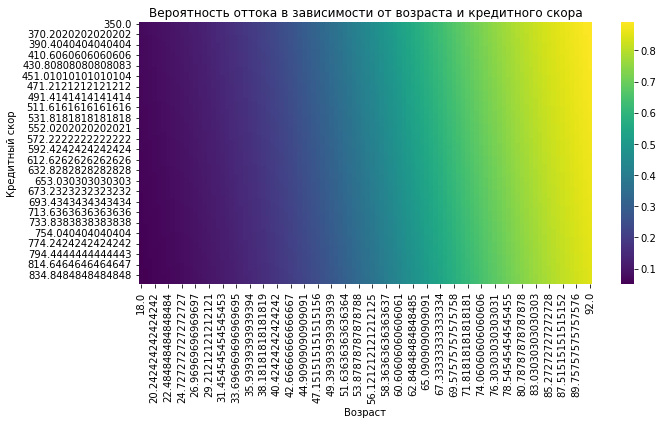

In [23]:
plt.figure(figsize=(10, 6))
pivot_table = prob_df.pivot_table(values='Churn_Probability', index='CreditScore', columns='Age')
sns.heatmap(pivot_table, cmap='viridis')
plt.title('Вероятность оттока в зависимости от возраста и кредитного скора')
plt.xlabel('Возраст')
plt.ylabel('Кредитный скор')
plt.tight_layout()
plt.show()

Вероятность оттока увеличивается с возрастом —  ось X, цвета становятся ярче

При более высоком кредитном скоре (ось Y), отток в целом ниже, особенно у молодых клиентов